# EDA датасета MicroLens-100K

## Цель анализа

Цель этапа — исследовать структуру взаимодействий пользователей с объектами,
распределение активности пользователей и популярности объектов, временную
структуру данных, разреженность матрицы взаимодействий и доступные текстовые
признаки.

В датасете используются две таблицы:

- `MicroLens-100k_pairs.csv` — взаимодействия пользователей с объектами;
- `MicroLens-100k_title_en.csv` — текстовые названия объектов.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from data_profiling import ProfileReport

In [2]:
data_path = Path("../../data/raw/microlens")
interactions_path = data_path / "MicroLens-100k_pairs.csv"
titles_path = data_path / "MicroLens-100k_title_en.csv"

assert interactions_path.exists()
assert titles_path.exists()

In [3]:
with open(interactions_path, "r") as file:
    print(file.readline())
    print(file.readline())
    print(file.readline())

user,item,timestamp

36121,9580,1583378629552

26572,9580,1583436719018



In [4]:
with open(titles_path, "r") as file:
    print(file.readline())
    print(file.readline())
    print(file.readline())

1, Gu long song gaga bad

2, beautiful dish with 5 pounds of duck intestines

3, This sudden reversal



## Первичный анализ данных о взаимодействиях

In [5]:
interaction_df = pd.read_csv(interactions_path)
interaction_df.head(10)

,user,item,timestamp
0,36121,9580,1583378629552
1,26572,9580,1583436719018
2,94805,9580,1584083806481
3,37550,9580,1584412681021
4,89825,9580,1584649439020
5,14601,9580,1584848802432
6,15061,9580,1585388171106
7,6364,9580,1585390736041
8,99661,9580,1585392581153
9,57849,9580,1585394954324


In [6]:
print("Размер таблицы взаимодействий:", interaction_df.shape)

Размер таблицы взаимодействий: (719405, 3)


In [7]:
profile_interaction = ProfileReport(interaction_df, title = "Interaction profile report")
profile_interaction

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00,  4.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
interaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719405 entries, 0 to 719404
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user       719405 non-null  int64
 1   item       719405 non-null  int64
 2   timestamp  719405 non-null  int64
dtypes: int64(3)
memory usage: 16.5 MB


In [9]:
interaction_df.isna().sum()

user         0
item         0
timestamp    0
dtype: int64

In [10]:
interaction_df.duplicated().sum()

np.int64(0)

In [11]:
n_users = interaction_df["user"].nunique()
n_items = interaction_df["item"].nunique()
n_interactions = len(interaction_df)

print("Количество пользователей:", n_users)
print("Количество объектов:", n_items)
print("Количество взаимодействий:", n_interactions)

Количество пользователей: 100000
Количество объектов: 19738
Количество взаимодействий: 719405


## Первичный анализ таблицы названий

In [12]:
titles_df = pd.read_csv(titles_path, header=None, names = ["item", "title"])
titles_df.head(10)

,item,title
0,1,Gu long song gaga bad
1,2,beautiful dish with 5 pounds of duck intestines
2,3,This sudden reversal
3,4,pumpkin play armor new outfit
4,5,the wife a day brush 200
5,6,What if the accompaniment suddenly stops? See...
6,7,become the North state family alliance leader...
7,8,a friend sent a box of sea urchins
8,9,salted fish brother: the method of fighting p...
9,10,Fatherland man may not be a nice guy


In [13]:
print("Размер таблицы названий:", titles_df.shape)

Размер таблицы названий: (19738, 2)


In [14]:
profile_titles = ProfileReport(titles_df, title = "Titles profile report")
profile_titles

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 12.40it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
titles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19738 entries, 0 to 19737
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   item    19738 non-null  int64 
 1   title   19738 non-null  object
dtypes: int64(1), object(1)
memory usage: 308.5+ KB


In [16]:
titles_df.isna().sum()

item     0
title    0
dtype: int64

In [17]:
titles_df.duplicated().sum()

np.int64(0)

## Активность пользователей и популярность объектов

In [18]:
user_interactions = interaction_df.groupby("user").size()
user_interactions.head()

user
1    5
2    7
3    5
4    5
5    5
dtype: int64

In [19]:
user_interactions.describe()

count    100000.000000
mean          7.194050
std           4.563348
min           5.000000
25%           5.000000
50%           6.000000
75%           8.000000
max         218.000000
dtype: float64

In [20]:
item_interactions = interaction_df.groupby("item").size()

In [21]:
item_interactions.describe()

count    19738.000000
mean        36.447715
std         43.571139
min          1.000000
25%          9.000000
50%         22.000000
75%         49.000000
max        640.000000
dtype: float64

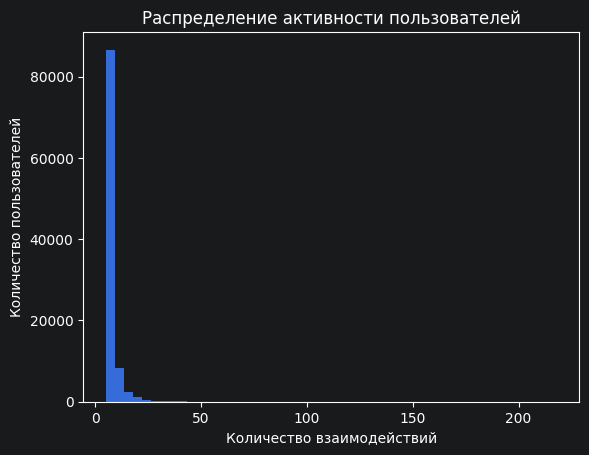

In [22]:
plt.hist(user_interactions, bins = 50)
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество пользователей")
plt.title("Распределение активности пользователей")
plt.show()

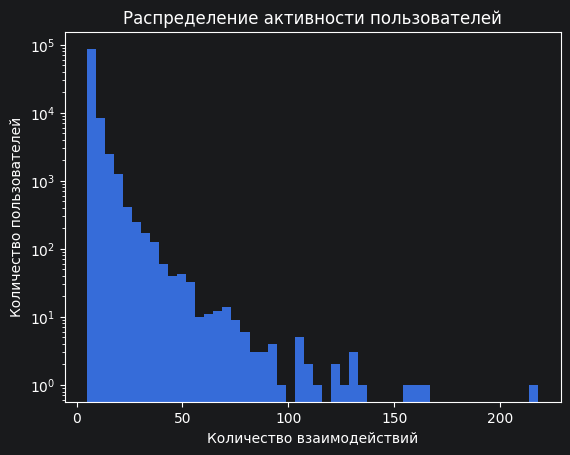

In [23]:
plt.hist(user_interactions, bins = 50)
plt.yscale("log")
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество пользователей")
plt.title("Распределение активности пользователей")
plt.show()

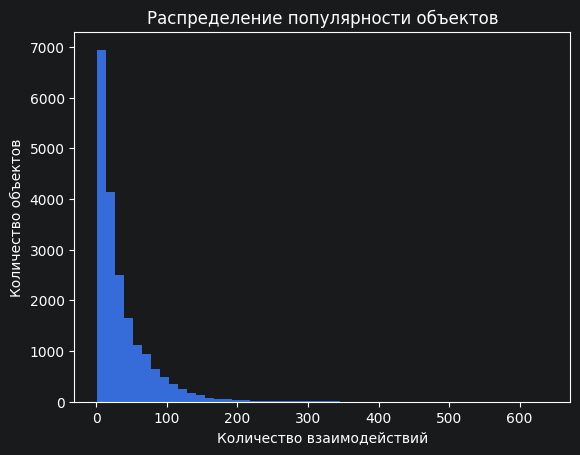

In [24]:
plt.hist(item_interactions, bins = 50)
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество объектов")
plt.title("Распределение популярности объектов")
plt.show()

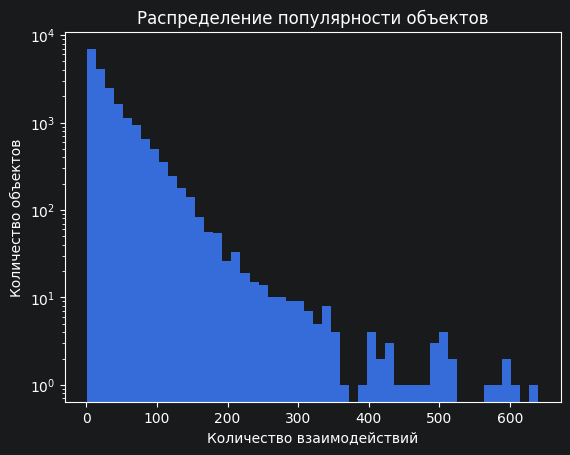

In [25]:
plt.hist(item_interactions, bins = 50)
plt.yscale("log")
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество объектов")
plt.title("Распределение популярности объектов")
plt.show()

In [26]:
item_interactions.sort_values(ascending = False).head(10)

item
16981    640
3260     604
15775    599
6539     590
16537    584
9512     564
7586     524
18361    519
680      505
15312    503
dtype: int64

Распределение популярности объектов скошено вправо: большинство объектов имеет небольшое число взаимодействий. Небольшая доля
объектов получает существенно больше взаимодействий.

In [27]:
user_item_counts = interaction_df.groupby(["user", "item"]).size()
user_item_counts.head(10)

user  item 
1     1707     1
      1958     1
      6346     1
      15223    1
      17700    1
2     915      1
      3775     1
      5299     1
      9127     1
      9500     1
dtype: int64

In [28]:
user_item_counts.max()

np.int64(1)

In [29]:
len(user_item_counts)

719405

In [30]:
len(interaction_df)

719405

### Вывод

Повторных взаимодействий одной и той же пары пользователь–объект в датасете
не обнаружено. Количество уникальных пар `user-item` совпадает с общим количеством
взаимодействий и составляет 719 405.
Таким образом, каждое наблюдение соответствует уникальной паре
пользователь–объект.

## Работа с timestamp

In [31]:
interaction_df["timestamp"].min()

np.int64(1583378629552)

In [32]:
interaction_df["timestamp"].max()

np.int64(1662984152842)

In [33]:
interaction_df["datetime"] = pd.to_datetime(interaction_df["timestamp"], unit="ms")
interaction_df.head()

,user,item,timestamp,datetime
0,36121,9580,1583378629552,2020-03-05 03:23:49.552
1,26572,9580,1583436719018,2020-03-05 19:31:59.018
2,94805,9580,1584083806481,2020-03-13 07:16:46.481
3,37550,9580,1584412681021,2020-03-17 02:38:01.021
4,89825,9580,1584649439020,2020-03-19 20:23:59.020


In [34]:
print("Начало периода:", interaction_df["datetime"].min())
print("Конец периода:", interaction_df["datetime"].max())

Начало периода: 2020-03-05 03:23:49.552000
Конец периода: 2022-09-12 12:02:32.842000


Временные метки взаимодействий пользователей представлены в формате Unix timestamp в миллисекундах.
Данные охватывают период с 5 марта 2020 года по 12 сентября 2022 года.
Наличие временной информации позволяет в дальнейшем использовать хронологическое разбиение данных и избежать утечки информации из будущего в обучающую выборку.

### Распределение взаимодействий во времени

In [35]:
interaction_by_month = interaction_df.groupby(interaction_df["datetime"].dt.to_period("M")).size()
interaction_by_month.head(20)

datetime
2020-03        11
2020-05         1
2021-10       209
2021-11        19
2021-12         8
2022-01       301
2022-02       340
2022-03      8873
2022-04     25754
2022-05     34570
2022-06     87109
2022-07    190746
2022-08    274791
2022-09     96673
Freq: M, dtype: int64

In [36]:
all_months = pd.period_range(start=interaction_by_month.index.min(), end=interaction_by_month.index.max(), freq="M")

In [37]:
interaction_by_month = interaction_by_month.reindex(all_months, fill_value=0)

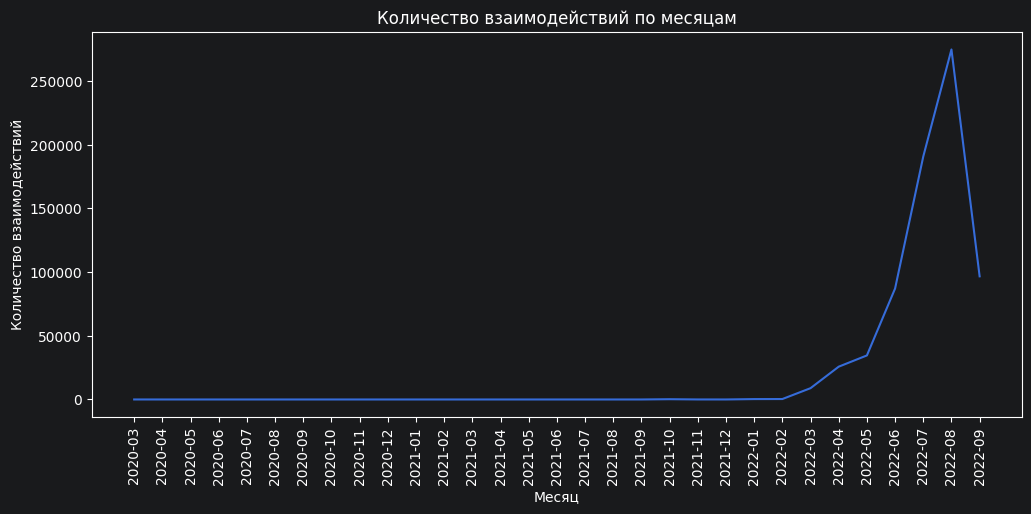

In [38]:
plt.figure(figsize=(12,5))
plt.plot(interaction_by_month.index.astype(str), interaction_by_month.values)
plt.xlabel("Месяц")
plt.ylabel("Количество взаимодействий")
plt.title("Количество взаимодействий по месяцам")

plt.xticks(rotation=90)
plt.show()

### Вывод

Временной диапазон данных охватывает период с марта 2020 года по сентябрь 2022 года, но взаимодействия распределены по времени неравномерно.
Основная часть данных приходится на период с марта по сентябрь 2022 года, а максимальная активность наблюдается в августе 2022 года.
Эту особенность необходимо учитывать при дальнейшем выборе способа разбиения данных на обучающую, валидационную и тестовую выборки.

### Исследование разреженности матрицы взаимодействий

In [39]:
n_possible_pairs = n_users * n_items
n_observed_pairs = len(user_item_counts)

density = n_observed_pairs / n_possible_pairs
sparsity = 1 - density

print("Всего возможных пар user-item:", n_possible_pairs)
print("Наблюдаемых пар user-item:", n_observed_pairs)
print(f"Плотность: {density*100:.4f}%")
print(f"Разреженность: {sparsity*100:.4f}%")

Всего возможных пар user-item: 1973800000
Наблюдаемых пар user-item: 719405
Плотность: 0.0364%
Разреженность: 99.9636%


### Вывод

Матрица взаимодействий MicroLens-100K является разреженной. Из 1 973 800 000 потенциальных пар `user-item` наблюдается
719 405 взаимодействий, что соответствует плотности 0.0364 %.
Разреженность матрицы более 99.9 %.

Это означает, что для подавляющего большинства пар пользователь–объект
взаимодействие не наблюдается. При этом отсутствие взаимодействия не следует
интерпретировать как отрицательную оценку пользователя, поскольку датасет
содержит неявную обратную связь.

Высокая разреженность также обосновывает использование разреженных структур
данных при дальнейшем построении рекомендательных моделей.

In [40]:
print("Уникальных объектов во взаимодействиях:", interaction_df["item"].nunique())
print("Уникальных объектов в таблице названий:", titles_df["item"].nunique())

Уникальных объектов во взаимодействиях: 19738
Уникальных объектов в таблице названий: 19738


In [41]:
items_without_title = (set(interaction_df["item"]) - set(titles_df["item"]))
len(items_without_title)

0

In [42]:
titles_without_interactions = (set(titles_df["item"]) - set(interaction_df["item"]))
len(titles_without_interactions)

0

### Вывод

Идентификаторы объектов в таблицах `interaction_df` и `titles_df` согласованы.

Для каждого объекта, встречающегося во взаимодействиях, присутствует
соответствующее текстовое название, и в таблице названий отсутствуют
объекты, не представленные в данных о взаимодействиях.

## EDA текстовых данных

In [43]:
titles_df.isna().sum()

item     0
title    0
dtype: int64

In [44]:
empty_titles = titles_df["title"].str.strip().eq("").sum()
print("Количество пустых названий:", empty_titles)

Количество пустых названий: 72


In [45]:
empty_titles_share = empty_titles / len(titles_df) * 100

print("Количество пустых названий:", empty_titles)
print(f"Доля пустых названий: {empty_titles_share:.3f} %")

Количество пустых названий: 72
Доля пустых названий: 0.365 %


In [46]:
titles_df["clean_title"] = titles_df["title"].str.strip()

In [47]:
titles_df["title_length"] = titles_df["clean_title"].str.len()

In [48]:
non_empty_titles = titles_df[titles_df["clean_title"] != ""]

In [49]:
titles_df["title_length"].describe()

count    19738.000000
mean        67.070828
std         42.826131
min          0.000000
25%         35.000000
50%         57.000000
75%         92.000000
max        640.000000
Name: title_length, dtype: float64

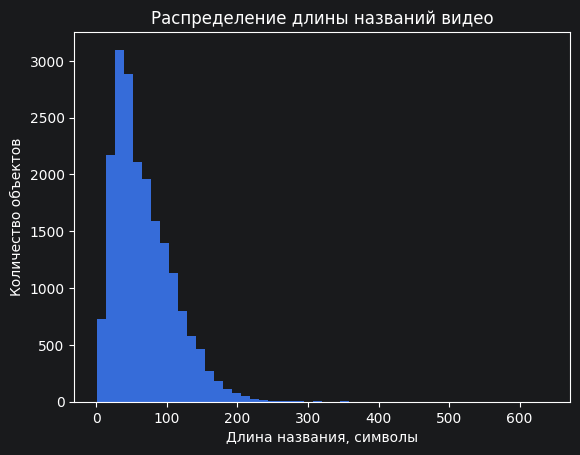

In [50]:
plt.hist(non_empty_titles["title_length"], bins=50)

plt.xlabel("Длина названия, символы")
plt.ylabel("Количество объектов")
plt.title("Распределение длины названий видео")

plt.show()

In [51]:
titles_df.sort_values("title_length").head(10)

,item,title,clean_title,title_length
9236,9237,,,0
16024,16025,,,0
7463,7464,,,0
6025,6026,,,0
14203,14204,,,0
1848,1849,,,0
6287,6288,,,0
16500,16501,,,0
5453,5454,,,0
7884,7885,,,0


In [52]:
titles_df.sort_values("title_length", ascending=False).head(10)

,item,title,clean_title,title_length
7099,7100,it is a pity that you do not see the star Han...,it is a pity that you do not see the star Han ...,640
19417,19418,25 Things to do before you graduate 1. Tell y...,25 Things to do before you graduate 1. Tell yo...,564
12011,12012,backstage... Qin Xiaoxian: Jiuhua ~ Qin Xiaox...,backstage... Qin Xiaoxian: Jiuhua ~ Qin Xiaoxi...,549
845,846,because the memories of you are too good. So ...,because the memories of you are too good. So i...,402
8417,8418,【picopark fifth set 】 Giants and dwarfs we ar...,【picopark fifth set 】 Giants and dwarfs we are...,352
1120,1121,18 years old and 20 years old birthday mounta...,18 years old and 20 years old birthday mountai...,348
14965,14966,episode 12 | The little Jewish scrimping and ...,episode 12 | The little Jewish scrimping and s...,338
11509,11510,have you seen all these movies? # High-scorin...,have you seen all these movies? # High-scoring...,328
15145,15146,Wu Lei Zhao Lu Si sweet abuse redemption! Bea...,Wu Lei Zhao Lu Si sweet abuse redemption! Beau...,312
14946,14947,never thought my dad is stalking me?? This is...,never thought my dad is stalking me?? This is ...,308


In [53]:
top_items = (item_interactions.sort_values(ascending=False).head(10).reset_index())
top_items.columns = ["item", "n_interactions"]

In [54]:
top_items = top_items.merge(titles_df[["item", "title"]], on="item")
top_items

,item,n_interactions,title
0,16981,640,crash professional team
1,3260,604,it was not easy for Kerry to win
2,15775,599,the peak of the national fifth
3,6539,590,confident but not boastful
4,16537,584,the young man is still too young
5,9512,564,I seem to say something
6,7586,524,forced to incarnate wild king orange
7,18361,519,Big Joe's top operation
8,680,505,peak game 2456 points national tenth in mind
9,15312,503,confidence is the peak


In [55]:
non_empty_titles["title_length"].describe()

count    19666.000000
mean        67.316384
std         42.711379
min          1.000000
25%         35.000000
50%         57.000000
75%         92.000000
max        640.000000
Name: title_length, dtype: float64

### Анализ длины текстовых названий

Большинство объектов имеет относительно короткие текстовые названия. Медианная длина названия: 57 символов, при этом
75% названий имеют длину не более 92 символов.

В датасете также присутствует правый хвост очень длинных
заголовков, максимальная длина которых достигает 640 символов.

Для 72 объектов текстовое название фактически отсутствует.

In [56]:
duplicate_titles = non_empty_titles[
    non_empty_titles["clean_title"].duplicated(keep=False)
].sort_values("clean_title")

print("Строк с повторяющимися названиями:", len(duplicate_titles))
print(
    "Различных повторяющихся названий:",
    duplicate_titles["clean_title"].nunique()
)

duplicate_titles.head(20)

Строк с повторяющимися названиями: 377
Различных повторяющихся названий: 131


,item,title,clean_title,title_length
4693,4694,# Dark zone I shot a wonderful video for # da...,# Dark zone I shot a wonderful video for # dar...,61
7600,7601,# Dark zone I shot a wonderful video for # da...,# Dark zone I shot a wonderful video for # dar...,61
13887,13888,# Darkzone I made a great video for # Darkzon...,# Darkzone I made a great video for # Darkzone...,55
7426,7427,# Darkzone I made a great video for # Darkzon...,# Darkzone I made a great video for # Darkzone...,55
19067,19068,# Darkzone I made a great video for # Darkzon...,# Darkzone I made a great video for # Darkzone...,74
3571,3572,# Darkzone I made a great video for # Darkzon...,# Darkzone I made a great video for # Darkzone...,74
14988,14989,# Darkzone I shot a great video for # Darkzon...,# Darkzone I shot a great video for # Darkzone...,55
18308,18309,# Darkzone I shot a great video for # Darkzon...,# Darkzone I shot a great video for # Darkzone...,55
16848,16849,# Darkzone I shot a wonderful video for # Dar...,# Darkzone I shot a wonderful video for # Dark...,59
7554,7555,# Darkzone I shot a wonderful video for # Dar...,# Darkzone I shot a wonderful video for # Dark...,59


После исключения пустых текстовых значений обнаружено 377 объектов,
входящих в группы с повторяющимися названиями. Всего найдено 131
различное повторяющееся название.

Повторяющиеся названия не рассматриваются как дубликаты объектов,
поскольку разные видео могут иметь одинаковый текстовый заголовок.

При построении текстовых представлений такие объекты могут получать
одинаковые или близкие эмбеддинги, поэтому дополнительные визуальные
признаки потенциально могут быть полезны для их различения.

In [57]:
title_counts = (non_empty_titles["clean_title"].value_counts())
title_counts.head(10)

clean_title
the wonderful video    25
in fact                12
guys                   10
as we all know          7
Original God            6
a wonderful video       6
sure enough             6
you build my guess      5
# won't stop at Tan     5
brothers                5
Name: count, dtype: int64

In [58]:
titles_df["word_count"] = (titles_df["clean_title"].str.split().str.len())
non_empty_titles = titles_df[titles_df["clean_title"] != ""]
non_empty_titles["word_count"].describe()

count    19666.000000
mean        12.399319
std          7.880680
min          1.000000
25%          6.000000
50%         11.000000
75%         17.000000
max        130.000000
Name: word_count, dtype: float64

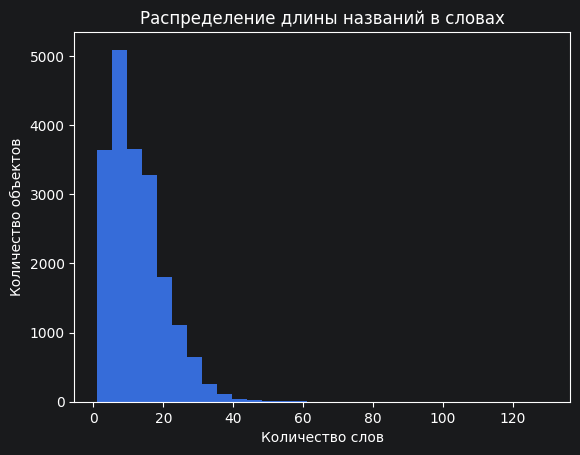

In [59]:
plt.hist(non_empty_titles["word_count"], bins=30)

plt.xlabel("Количество слов")
plt.ylabel("Количество объектов")
plt.title("Распределение длины названий в словах")

plt.show()

In [60]:
item_interactions.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.10      4.0
0.25      9.0
0.50     22.0
0.75     49.0
0.90     87.0
0.95    115.0
0.99    193.0
dtype: float64

Популярность объектов по квантилям:

- 10% объектов имеют не более 4 взаимодействий;
- 25% — не более 9;
- 50% — не более 22;
- 75% — не более 49;
- 90% — не более 87;
- 95% — не более 115;
- 99% — не более 193.

Эти значения будут использоваться при дальнейшем выборе способа
разделения объектов по объёму доступного коллаборативного сигнала.

# Итоги EDA MicroLens-100K

В датасете содержится 100 000 пользователей, 19 738 объектов и
719 405 уникальных взаимодействий `user-item`.

Пропуски и полные дубликаты в таблице взаимодействий отсутствуют.
Повторных взаимодействий одной и той же пары `user-item` не обнаружено.

Пользовательские истории преимущественно короткие: медианное количество
взаимодействий составляет 6, а 75% пользователей имеют не более
8 взаимодействий.

Популярность объектов существенно неоднородна. Медианное количество
взаимодействий с объектом составляет 22, а значения изменяются от 1 до 640.
Распределение имеет выраженный правый хвост.

Матрица взаимодействий является крайне разреженной: наблюдается
0.0364% всех потенциальных пар `user-item`, а разреженность составляет 99.9 %.

Временной диапазон охватывает период с марта 2020 года
по сентябрь 2022 года, однако взаимодействия распределены крайне
неравномерно и в основном сосредоточены в 2022 году.

Текстовые названия:
72 объекта (около 0.365%) имеют пустое название.
Медианная длина непустого названия составляет 57 символов и 11 слов.

Обнаружены также разные объекты с одинаковыми текстовыми названиями:
377 объектов входят в группы, соответствующие 131 повторяющемуся названию.

Таким образом, MicroLens-100K содержит объекты с существенно различным
объёмом коллаборативной информации и пригоден для дальнейшего исследования
влияния контентных представлений при различной надёжности
коллаборативного сигнала.

Следующим этапом является разработка корректного протокола разбиения
данных на обучающую, валидационную и тестовую части.